<img src="../figs/holberton_logo.png" alt="logo" width="500"/>

# Data Processing and Exploration using Titanic Dataset

### Load the Titanic Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = sns.load_dataset('titanic')
print(titanic_df.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### Titanic dataset fundamentals

#### What are the dimensions of the dataset?


In [2]:
titanic_df.shape

(891, 15)

#### What are the column names and their data types?

In [3]:
titanic_df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

#### How much missing data is there in each column?

In [4]:
titanic_df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

#### What are summary statistics for numerical columns?

In [5]:
titanic_df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### What is the distribution of categorical variables?

In [6]:
titanic_df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

#### What is the survival rate among different passenger classes (Pclass)?

In [10]:
titanic_df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

#### What was the average fare paid by passengers who survived vs. those who did not?

In [12]:
titanic_df.groupby('survived')['fare'].mean()

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

#### How did the survival rate vary between different embarkation ports (C, Q, S)?

In [16]:
titanic_df.groupby('embarked')['survived'].mean()

embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64

#### What was the survival rate for passengers with family members (SibSp or Parch) onboard vs. those traveling alone?

In [22]:
titanic_df['family'] = titanic_df['sibsp'] + titanic_df['parch']
titanic_df.groupby(titanic_df['family'] > 0)['survived'].mean()

family
False    0.303538
True     0.505650
Name: survived, dtype: float64

### Titanic Dataset Visualization

#### What is the distribution of passenger ages on the Titanic?

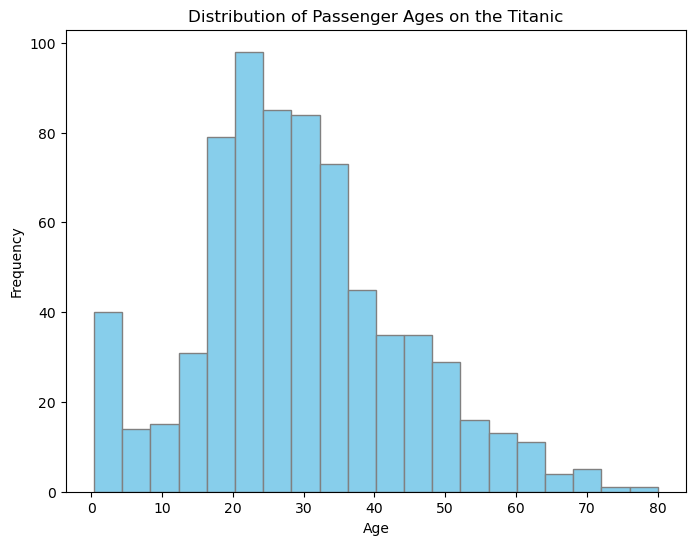

In [30]:
plt.figure(figsize=(8, 6))
plt.hist(titanic_df['age'].dropna(), bins=20, color='skyblue', edgecolor='gray')
plt.title('Distribution of Passenger Ages on the Titanic')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

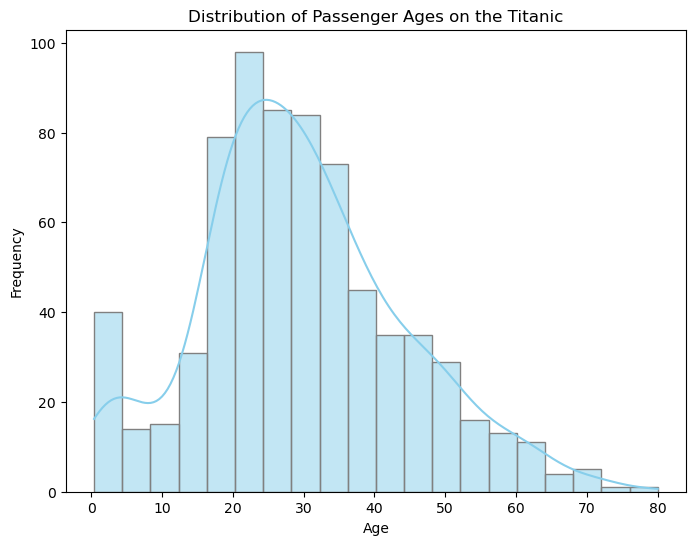

In [33]:
plt.figure(figsize=(8, 6))
sns.histplot(data=titanic_df, x='age', color='skyblue', edgecolor='gray', bins=20, kde=True)
plt.title('Distribution of Passenger Ages on the Titanic')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#### How does the survival rate vary by passenger class (Pclass)?

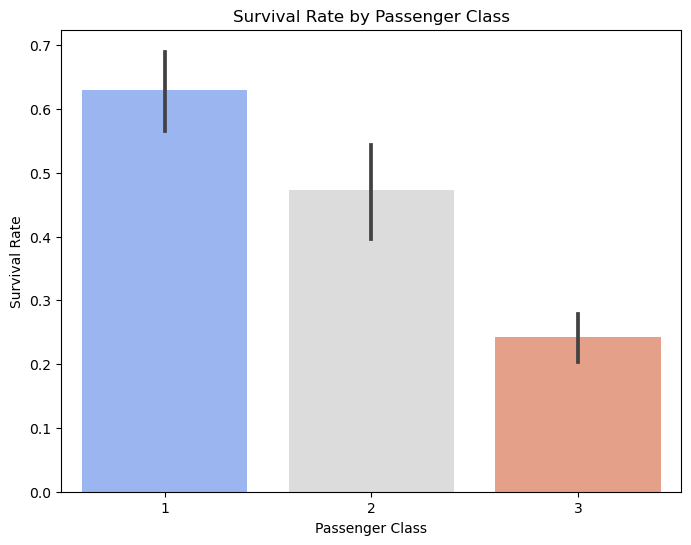

In [36]:
plt.figure(figsize=(8, 6))
sns.barplot(x='pclass', y='survived', palette='coolwarm', data=titanic_df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

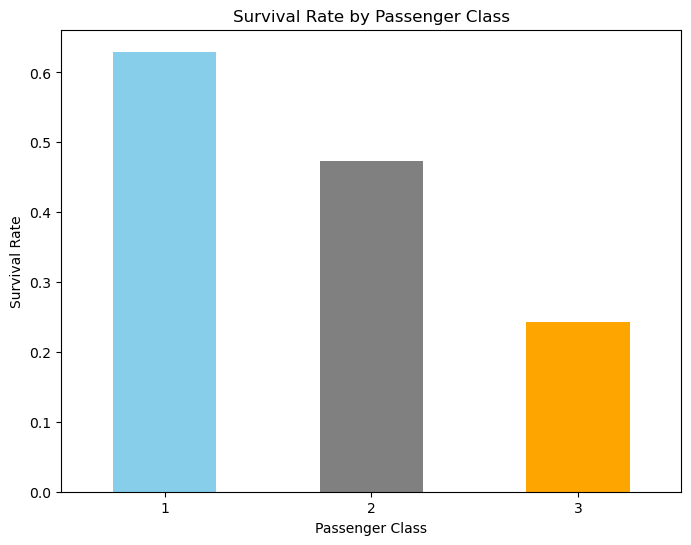

In [43]:
plt.figure(figsize=(8, 6))
titanic_df.groupby('pclass')['survived'].mean().plot(kind='bar', rot=0, color=['skyblue', 'gray', 'orange'])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

#### What is the gender distribution among passengers?

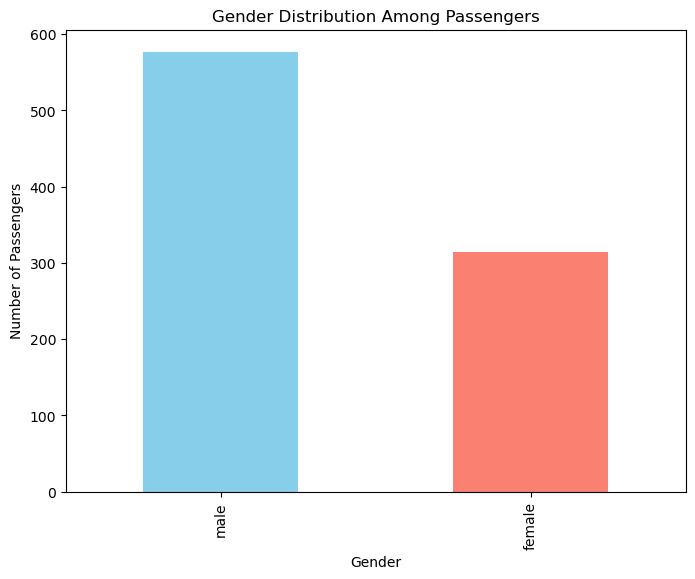

In [47]:
plt.figure(figsize=(8, 6))
titanic_df['sex'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Gender Distribution Among Passengers')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

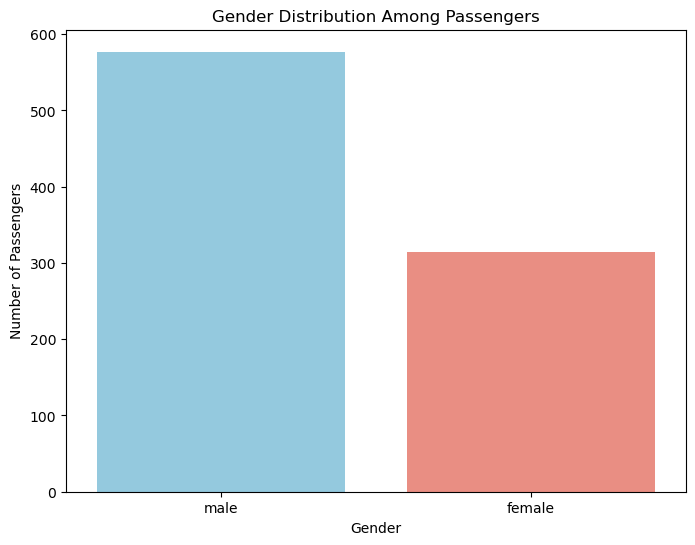

In [46]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', data=titanic_df, palette=['skyblue', 'salmon'])
plt.title('Gender Distribution Among Passengers')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

#### How does survival vary by age and gender?

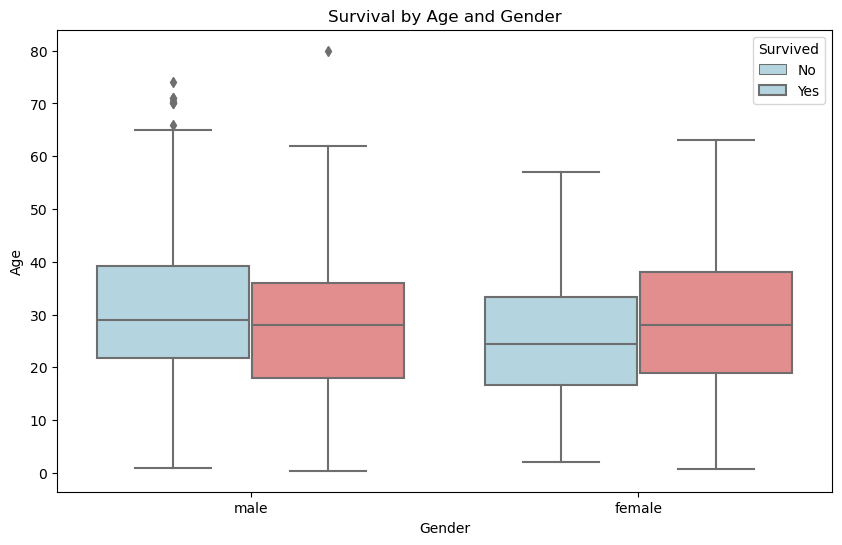

In [48]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='age', hue='survived', data=titanic_df, palette=['lightblue', 'lightcoral'])
plt.title('Survival by Age and Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.legend(title='Survived', loc='upper right', labels=['No', 'Yes'])
plt.show()

#### What was the distribution of survival among different embarkation ports?

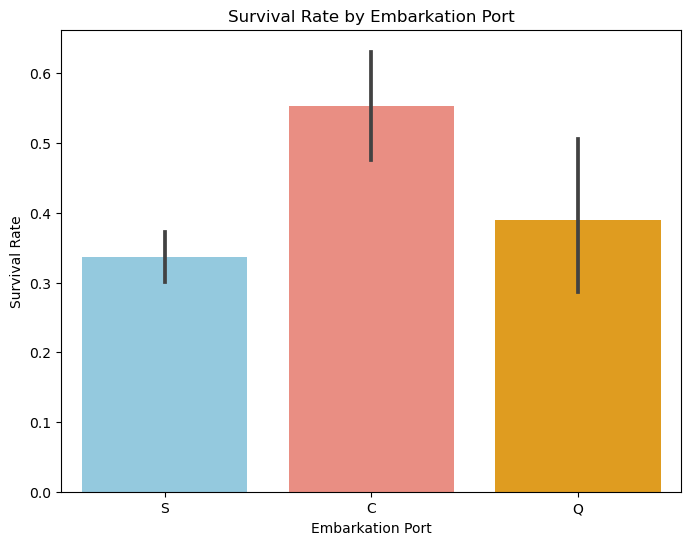

In [50]:
plt.figure(figsize=(8, 6))
sns.barplot(x='embarked', y='survived', data=titanic_df, palette=['skyblue', 'salmon', 'orange'])
plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

#### Missing values

1. How many missing values are there in each column?
2. What strategy should be used to handle missing values in the 'age' column?
3. What strategy should be used to handle missing values in the 'deck' column?
4. What strategy should be used to handle missing values in the 'embark_town' column?
5. Are there any other columns with missing values that need to be addressed?

#### Convert the gender categorical variable to numerical